# Data Exploration with Python

**Learning Goal:** Use Claude Code to explore Bolivia's sustainable development data.

This notebook demonstrates:
- Loading data using project configuration
- Basic data inspection
- Summary statistics
- Identifying patterns and relationships

## Setup

First, we load our project configuration and required libraries.

In [1]:
import sys
sys.path.insert(0, '..')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load project configuration
from config import DATA_DIR, OUTPUT_DIR, set_seeds

# Set seeds for reproducibility
set_seeds()

# Display settings
pd.set_option('display.max_columns', 50)
pd.set_option('display.width', 120)

print(f"Data directory: {DATA_DIR}")

Data directory: /Users/carlosmendez/Documents/GitHub/claude4data/data


## Load the Datasets

We have 4 datasets that can be joined via `asdf_id`:
1. **regionNames** - Municipality identifiers
2. **sdg** - SDG index scores (0-100)
3. **sdgVariables** - Detailed SDG indicators
4. **ntl** - Night-time lights (economic proxy)

In [2]:
# Load all datasets
regions = pd.read_csv(DATA_DIR / 'regionNames' / 'regionNames.csv')
sdg = pd.read_csv(DATA_DIR / 'sdg' / 'sdg.csv')
sdg_vars = pd.read_csv(DATA_DIR / 'sdgVariables' / 'sdgVariables.csv')
ntl = pd.read_csv(DATA_DIR / 'ntl' / 'ln_NTLpc.csv')

print(f"Regions: {regions.shape}")
print(f"SDG indices: {sdg.shape}")
print(f"SDG variables: {sdg_vars.shape}")
print(f"Night-time lights: {ntl.shape}")

Regions: (339, 8)
SDG indices: (339, 17)
SDG variables: (339, 65)
Night-time lights: (339, 19)


## Inspect the Data

Let's look at each dataset's structure.

In [3]:
# Region names - administrative metadata
print("=== REGION NAMES ===")
print(regions.head())
print(f"\nColumns: {list(regions.columns)}")

=== REGION NAMES ===
   poly_id  asdf_id             mun  mun_id     dep  dep_id               dep_mun                     shapeID
0      178        0       Esmeralda   40505   Oruro       5       Oruro-Esmeralda  BOL-ADM3-33444609B20338026
1      169        1       Quillacas   40202   Oruro       5       Oruro-Quillacas  BOL-ADM3-33444609B53994240
2      185        2  Pampa Aullagas   40802   Oruro       5  Oruro-Pampa Aullagas  BOL-ADM3-33444609B27878331
3      205        3       Llallagua   50203  Potosí       7      Potosí-Llallagua  BOL-ADM3-33444609B13957296
4      219        4        Caripuyo   50702  Potosí       7       Potosí-Caripuyo   BOL-ADM3-33444609B2060227

Columns: ['poly_id', 'asdf_id', 'mun', 'mun_id', 'dep', 'dep_id', 'dep_mun', 'shapeID']


In [4]:
# SDG indices - composite scores
print("=== SDG INDICES ===")
print(sdg.head())
print(f"\nColumns: {list(sdg.columns)}")

=== SDG INDICES ===
   asdf_id       imds  index_sdg1  index_sdg2  index_sdg3  index_sdg4  index_sdg5  index_sdg6  index_sdg7  index_sdg8  \
0        0  53.200001   34.759998   55.080002   85.690002   68.860001   58.529999   34.540001   52.230000   30.920000   
1        1  50.500000   27.950001   34.820000   70.199997   57.730000   87.529999   21.840000   50.110001   56.599998   
2        2  47.299999   18.910000   54.580002   72.820000   48.720001   77.480003   22.480000   45.450001   35.470001   
3        3  58.099998   60.480000   34.730000   72.260002   66.889999   72.970001   53.049999   69.360001   47.439999   
4        4  43.500000   18.889999   32.189999   59.919998   49.669998   77.059998   33.660000   36.000000   49.000000   

   index_sdg9  index_sdg10  index_sdg11  index_sdg13  index_sdg15  index_sdg16  index_sdg17  
0   24.530001    83.940002    32.560001    77.379997         50.0    82.400002    26.889999  
1   46.639999    74.089996    30.680000    75.440002         50.0

In [5]:
# Night-time lights - economic activity proxy
print("=== NIGHT-TIME LIGHTS ===")
print(ntl.head())
print(f"\nColumns: {list(ntl.columns)}")

=== NIGHT-TIME LIGHTS ===
   asdf_id  ln_NTLpc2012  ln_NTLpc2013  ln_NTLpc2014  ln_NTLpc2015  ln_NTLpc2016  ln_NTLpc2017  ln_NTLpc2018  \
0        0     11.729473     12.111817     10.962022     11.699198     13.085610     13.647187     13.667681   
1        1     12.965525     13.142761     13.074501     13.143079     12.948340     13.821883     13.822321   
2        2     12.763059     12.927601     12.876277     12.199938     12.289141     13.406137     13.358246   
3        3     14.275025     14.395530     14.490864     14.518698     14.763354     14.827301     14.902343   
4        4     11.708997     12.142770     11.809417     11.976866     11.590055     12.510039     12.694351   

   ln_NTLpc2019  ln_NTLpc2020  ln_t400NTLpc2012  ln_t400NTLpc2013  ln_t400NTLpc2014  ln_t400NTLpc2015  \
0     13.595437     13.489282         11.414175         11.726494         12.039332         12.354541   
1     13.803769     14.016370         12.862933         12.999367         13.136051        

## Merge Datasets

Create a combined dataset for analysis.

In [6]:
# Merge all datasets on asdf_id
df = regions.merge(sdg, on='asdf_id')
df = df.merge(ntl, on='asdf_id')

print(f"Combined dataset: {df.shape}")
print(f"\nColumns: {list(df.columns)}")

Combined dataset: (339, 42)

Columns: ['poly_id', 'asdf_id', 'mun', 'mun_id', 'dep', 'dep_id', 'dep_mun', 'shapeID', 'imds', 'index_sdg1', 'index_sdg2', 'index_sdg3', 'index_sdg4', 'index_sdg5', 'index_sdg6', 'index_sdg7', 'index_sdg8', 'index_sdg9', 'index_sdg10', 'index_sdg11', 'index_sdg13', 'index_sdg15', 'index_sdg16', 'index_sdg17', 'ln_NTLpc2012', 'ln_NTLpc2013', 'ln_NTLpc2014', 'ln_NTLpc2015', 'ln_NTLpc2016', 'ln_NTLpc2017', 'ln_NTLpc2018', 'ln_NTLpc2019', 'ln_NTLpc2020', 'ln_t400NTLpc2012', 'ln_t400NTLpc2013', 'ln_t400NTLpc2014', 'ln_t400NTLpc2015', 'ln_t400NTLpc2016', 'ln_t400NTLpc2017', 'ln_t400NTLpc2018', 'ln_t400NTLpc2019', 'ln_t400NTLpc2020']


## Summary Statistics

Explore the distribution of SDG indices across Bolivia's municipalities.

In [7]:
# SDG index columns
sdg_cols = [col for col in df.columns if col.startswith('index_sdg')]
print(f"SDG indices: {sdg_cols}")

# Summary statistics
df[sdg_cols].describe().round(2)

SDG indices: ['index_sdg1', 'index_sdg2', 'index_sdg3', 'index_sdg4', 'index_sdg5', 'index_sdg6', 'index_sdg7', 'index_sdg8', 'index_sdg9', 'index_sdg10', 'index_sdg11', 'index_sdg13', 'index_sdg15', 'index_sdg16', 'index_sdg17']


,index_sdg1,index_sdg2,index_sdg3,index_sdg4,index_sdg5,index_sdg6,index_sdg7,index_sdg8,index_sdg9,index_sdg10,index_sdg11,index_sdg13,index_sdg15,index_sdg16,index_sdg17
count,339.00,339.00,339.00,339.00,339.00,339.00,339.00,339.00,339.00,339.00,339.00,339.00,339.00,339.00,339.00
mean,37.46,40.68,75.21,53.25,73.06,35.80,52.26,44.98,35.53,66.05,37.54,72.22,53.89,73.84,14.01
std,20.95,11.05,7.36,12.11,9.72,16.23,14.93,10.51,15.20,14.22,12.52,15.49,18.82,9.68,11.61
min,0.06,21.44,50.23,12.37,37.79,0.00,24.94,14.95,0.62,10.26,3.05,11.90,0.00,32.72,0.00
25%,21.64,30.78,70.38,46.61,68.28,25.49,40.94,38.12,24.33,57.95,29.77,64.93,49.79,69.06,5.69
50%,34.76,37.98,76.17,54.38,74.24,34.92,50.15,45.20,34.91,68.62,36.71,77.41,50.00,75.63,10.89
75%,51.88,49.11,80.75,61.11,79.62,44.70,62.29,51.92,46.04,75.69,43.42,82.00,53.59,80.40,18.31
max,90.46,71.37,89.05,85.82,93.54,95.01,96.53,72.51,78.86,95.71,94.81,99.77,100.00,93.66,65.25


In [8]:
# Overall development index (IMDS)
print("=== Municipal Sustainable Development Index (IMDS) ===")
print(df['imds'].describe())
print(f"\nTop 5 municipalities:")
print(df.nlargest(5, 'imds')[['mun', 'dep', 'imds']])

=== Municipal Sustainable Development Index (IMDS) ===
count    339.000000
mean      51.050442
std        6.771824
min       35.700001
25%       47.000000
50%       50.500000
75%       54.850001
max       80.199997
Name: imds, dtype: float64

Top 5 municipalities:
             mun         dep       imds
176       La Paz      La Paz  80.199997
135   Cochabamba  Cochabamba  73.699997
101       Tarija      Tarija  70.599998
79   Quillacollo  Cochabamba  69.800003
254        Sucre  Chuquisaca  69.599998


In [9]:
# Department-level summary
print("=== IMDS by Department ===")
dept_summary = df.groupby('dep')['imds'].agg(['mean', 'std', 'min', 'max', 'count'])
dept_summary = dept_summary.round(2).sort_values('mean', ascending=False)
print(dept_summary)

=== IMDS by Department ===
             mean   std   min   max  count
dep                                       
Tarija      60.60  5.50  51.8  70.6     11
Santa Cruz  54.29  4.80  42.7  64.1     56
Cochabamba  52.50  8.50  39.4  73.7     47
La Paz      50.98  5.37  41.8  80.2     87
Oruro       50.68  5.03  42.9  67.4     35
Beni        50.47  4.50  43.9  61.3     19
Chuquisaca  47.80  6.60  35.7  69.6     29
Potosí      47.40  7.55  36.3  66.2     40
Pando       45.43  5.59  36.4  57.1     15


## Quick Visualizations

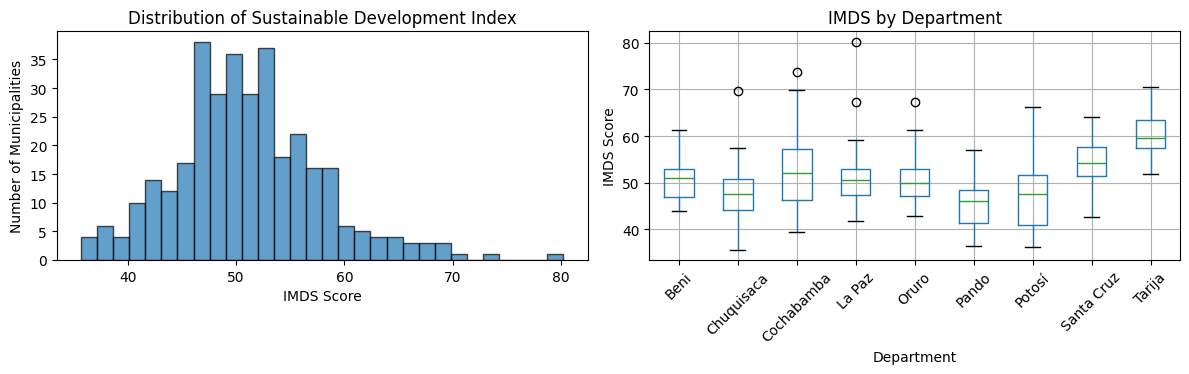

In [10]:
# Distribution of IMDS
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Histogram
axes[0].hist(df['imds'], bins=30, edgecolor='black', alpha=0.7)
axes[0].set_xlabel('IMDS Score')
axes[0].set_ylabel('Number of Municipalities')
axes[0].set_title('Distribution of Sustainable Development Index')

# Boxplot by department
df.boxplot(column='imds', by='dep', ax=axes[1], rot=45)
axes[1].set_xlabel('Department')
axes[1].set_ylabel('IMDS Score')
axes[1].set_title('IMDS by Department')
plt.suptitle('')

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'imds_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

## Your Turn!

Try asking Claude Code to help you with:
- "Show me the correlation between SDG indices"
- "Which municipalities have the lowest SDG1 (poverty) scores?"
- "Plot night-time lights over time for a specific department"
- "Compare urban vs rural municipalities"

In [11]:
# Space for your exploration
